<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/Week03-MLR/Lab3-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multivariate linear regresion


In [1]:
#!pip install ipython-autotime

In [2]:
%load_ext autotime

time: 284 µs (started: 2026-08-27 11:47:01 +00:00)


In [3]:
import numpy as np
np.set_printoptions(precision=2)
from sklearn.datasets import make_regression

mRow = 200_000
x, y = make_regression(n_samples=mRow, n_features=400, noise=2, random_state=123)
x_b = np.c_[np.ones((x.shape[0],1)),x]
y = y.reshape(-1,1)



time: 12.9 s (started: 2026-08-27 11:47:01 +00:00)


In [4]:
epsilon = 0.001
miter = 1000
eta = 0.01
# initial theta


time: 816 µs (started: 2026-08-27 11:47:14 +00:00)


# **Batch Gradient descent (Multiple linear regression)**


In [5]:
def cost_function(theta, x, y, N): #mse
  y_hat = x.dot(theta)
  c = (1/N)*np.sum((y_hat-y)**2)
  return c

time: 760 µs (started: 2026-08-27 11:47:14 +00:00)


In [6]:
import random
import math
import numpy as np # Explicitly importing numpy

def gradient_descent(alpha, x, y, ep=0.001, max_iter=10000, random_state=None):
  converged = False
  iter_count = 0
  N = x.shape[0] # number of samples

  # Set random state for reproducibility if provided
  if random_state is not None:
      rng = np.random.default_rng(random_state)
  else:
      rng = np.random.default_rng() # Use default if no seed is provided

  theta =  rng.random((x_b.shape[1],1))

  theta_history = [theta.flatten()] # Store initial theta state
  cost_history = [] # Store cost at each step

  # total error, J(theta)
  J = cost_function(theta, x, y, N)
  cost_history.append(J) # Store initial cost
  print("First J = ",J)

  # Iterate Loop
  while not converged:

    y_hat = x.dot(theta)
    diff = y_hat - y
    grad = x.T.dot(diff)

    theta = theta - alpha * (1/N) * (grad)
    theta_history.append(theta.flatten()) # Store theta at each step

    # error
    J2 = cost_function(theta, x, y, N)
    cost_history.append(J2) # Store cost at each step

    if abs(J-J2) <= ep:
        print("       Converged, iterations: ", iter_count, "/", max_iter , ", error J = ",J) # Commented out verbose printing
        converged = True

    J = J2   # update error s
    iter_count += 1  # update iter

    if iter_count == max_iter:
        print('       Max iterations exceeded!') # Commented out verbose printing
        converged = True

    if math.floor(iter_count % 100) == 0:
      print("iter = ",iter_count, ", error = ", J)

  return theta, np.array(theta_history), np.array(cost_history)

time: 4.56 ms (started: 2026-08-27 11:47:14 +00:00)


In [7]:
if __name__ == '__main__':
  print("start main")
  alpha = eta
  # Updated call to gradient_descent to capture all returned values and pass random_state
  theta, theta_history_original, cost_history_original = gradient_descent(alpha, x_b, y, ep=epsilon, max_iter=miter, random_state=42)
  print ("Theta = ", theta[0:5])

start main
First J =  25860.169118601025
iter =  100 , error =  3463.57710249209
iter =  200 , error =  471.3728422999535
iter =  300 , error =  67.7357818745938
iter =  400 , error =  12.76611449413002
iter =  500 , error =  5.2102114255570235
iter =  600 , error =  4.162258896781918
       Converged, iterations:  662 / 1000 , error J =  4.04222916506396
Theta =  [[-0.]
 [-0.]
 [ 0.]
 [ 0.]
 [-0.]]
time: 2min 5s (started: 2026-08-27 11:47:14 +00:00)


# Stochastic GD
## Your turn :)

In [8]:
import random
import math
import numpy as np

def sgd(alpha, x, y, ep=0.001, max_iter=10000, random_state=None):
  converged = False
  iter_count = 0 # Renamed 'iter' to 'iter_count'
  N = x.shape[0] # number of samples

  # Set random state for reproducibility if provided
  if random_state is not None:
      rng = np.random.default_rng(random_state)
  else:
      rng = np.random.default_rng() # Use default if no seed is provided

  # initial theta
  theta =  rng.random((x.shape[1],1))

  theta_history = [theta.flatten()] # Store initial theta state
  cost_history = [] # Store cost at each step

  # total error, J(theta)
  J = cost_function(theta, x, y, N)
  print("First J = ",J)
  cost_history.append(J) # Store initial cost

  shuffle = np.random.permutation(N)
  x = x[shuffle]
  y = y[shuffle]

  rIndex = 0
  # Iterate Loop
  while not converged:

    # Select one random row index for SGD
    xr = x[rIndex].reshape(1,-1)
    y_hat = xr.dot(theta)

    diff = y_hat - y[rIndex]
    diff = diff.reshape(-1,1)
    # For SGD, gradient is typically calculated for a single sample, not averaged over N
    grad = xr.T.dot(diff)

    # Update theta. Note: Some SGD implementations might not divide by N here.
    # We'll keep it consistent with the original batch GD scaling for this example.
    theta = theta - alpha * (grad)
    theta_history.append(theta.flatten()) # Store theta at each step

    alpha = alpha/(1+(alpha*0.1*iter_count)) # Use iter_count for alpha decay

    # error
    J2 = cost_function(theta, x, y, N)
    #print("J2 = ",J2)
    cost_history.append(J2) # Store cost at each step

    if abs(J-J2) <= ep:
        converged = True
        print("       Converged, iterations: ", iter_count, "/", max_iter, ", error J = ",J)

    J = J2   # update error s
    iter_count += 1  # update iter

    if iter_count == max_iter:
      converged = True
      print('       Max iterations exceeded!')

    if math.floor(iter_count % 100) == 0:
      print("iter = ",iter_count, ", error = ", J)

    rIndex += 1
    if rIndex >= N:
      rIndex = 0
      shuffle = np.random.permutation(N)
      x = x[shuffle]
      y = y[shuffle]

  return theta, np.array(theta_history), np.array(cost_history)

time: 3.11 ms (started: 2026-08-27 11:49:19 +00:00)


In [9]:
if __name__ == '__main__':
  print("start main")
  alpha = eta
  # Updated call to sgd to capture all returned values and pass random_state
  theta, theta_history_original_sgd, cost_history_original_sgd = sgd(alpha, x_b, y, ep=epsilon, max_iter=miter, random_state=42)
  print ("Theta = ", theta[0:5])

start main
First J =  25860.169118601025
iter =  100 , error =  41509.124650317055
iter =  200 , error =  35308.84255869444
       Converged, iterations:  287 / 1000 , error J =  33293.7163703234
Theta =  [[ 15.51]
 [-13.26]
 [  5.31]
 [ -3.53]
 [  1.47]]
time: 16.6 s (started: 2026-08-27 11:49:19 +00:00)


# Mini-batch GD (b = 1000)
## Your turn :)

In [10]:
import random
import math
import numpy as np

def mbgd(alpha, x, y, ep=0.001, max_iter=10000, batch_size=1000, random_state=None):
  converged = False
  iter_count = 0
  N = x.shape[0] # total number of samples

  # Set random state for reproducibility if provided
  if random_state is not None:
      rng = np.random.default_rng(random_state)
  else:
      rng = np.random.default_rng() # Use default if no seed is provided

  # initial theta
  theta = rng.random((x.shape[1],1))

  theta_history = [theta.flatten()] # Store initial theta state
  cost_history = [] # Store cost at each step

  # total error, J(theta) - calculated on the full dataset for monitoring
  J = cost_function(theta, x, y, N)
  print("First J = ",J)
  cost_history.append(J) # Store initial cost

  # Main loop
  while not converged:

    # Shuffle data at the start of each epoch
    if iter_count % (N // batch_size) == 0: # Check if a new epoch starts
        shuffle_indices = np.random.permutation(N)
        x_shuffled = x[shuffle_indices]
        y_shuffled = y[shuffle_indices]

    # Get current mini-batch
    start_idx = (iter_count * batch_size) % N
    end_idx = min(start_idx + batch_size, N)

    # Handle the case where the last batch might be smaller
    x_batch = x_shuffled[start_idx:end_idx]
    y_batch = y_shuffled[start_idx:end_idx]
    N_batch = x_batch.shape[0]

    y_hat_batch = x_batch.dot(theta)
    diff_batch = y_hat_batch - y_batch
    grad = x_batch.T.dot(diff_batch)

    # Update theta. Divide by batch_size for proper averaging of gradients.
    theta = theta - alpha * (1/N_batch) * (grad)
    theta_history.append(theta.flatten()) # Store theta at each step

    # Learning rate decay (can be adjusted for MBGD)
    # alpha = alpha/(1+(alpha*0.01*iter_count)) # Slightly different decay factor

    # Error (cost) - calculated on the full dataset for consistent monitoring
    J2 = cost_function(theta, x, y, N)
    cost_history.append(J2) # Store cost at each step

    if abs(J-J2) <= ep:
        converged = True
        print("       Converged, iterations: ", iter_count, "/", max_iter, ", error J = ",J)

    J = J2   # update error s
    iter_count += 1  # update iter

    if iter_count == max_iter:
      converged = True
      print('       Max iterations exceeded!')

    # Optional: Print progress every X iterations (e.g., every 100 mini-batch updates)
    if math.floor(iter_count % 100) == 0:
      print("iter = ",iter_count, ", error = ", J)

  return theta, np.array(theta_history), np.array(cost_history)

time: 3.6 ms (started: 2026-08-27 11:49:36 +00:00)


In [11]:
if __name__ == '__main__':
  print("start main for Mini-batch GD")

  alpha = eta # Learning rate for MBGD
  batch_size = 256 # As suggested by the text cell

  # Run Mini-batch Gradient Descent and pass random_state
  theta_mbgd, theta_history_original_mbgd, cost_history_original_mbgd = mbgd(alpha, x_b, y, ep=epsilon, max_iter=miter, batch_size=batch_size, random_state=42)

  print ("Theta (first 5 elements) = ", theta_mbgd[0:5])

start main for Mini-batch GD
First J =  25860.169118601025
iter =  100 , error =  3548.792158497476
iter =  200 , error =  490.77713515470606
iter =  300 , error =  69.88448142551049
iter =  400 , error =  12.957654377594219
iter =  500 , error =  5.2229326219491545
iter =  600 , error =  4.177820354306865
       Converged, iterations:  614 / 1000 , error J =  4.135902570861526
Theta (first 5 elements) =  [[ 0.  ]
 [ 0.01]
 [ 0.01]
 [ 0.01]
 [-0.02]]
time: 36.3 s (started: 2026-08-27 11:49:36 +00:00)


### Comparison of Cost Histories: BGD and MBGD

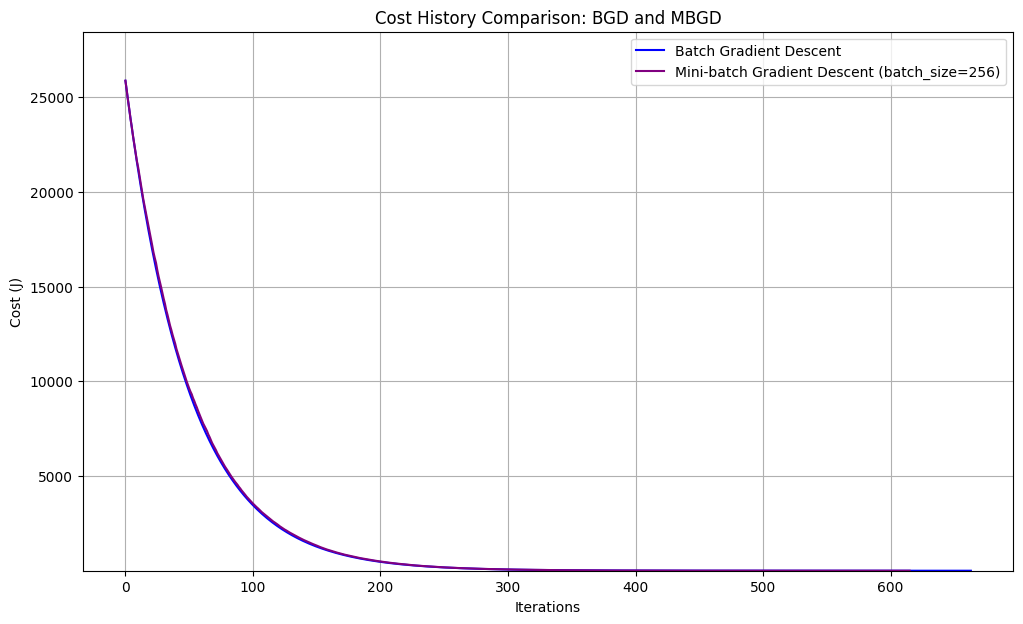

time: 179 ms (started: 2026-08-27 11:50:29 +00:00)


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot BGD Cost History
plt.plot(range(len(cost_history_original)), cost_history_original, color='blue', label='Batch Gradient Descent')

# Plot MBGD Cost History
plt.plot(range(len(cost_history_original_mbgd)), cost_history_original_mbgd, color='purple', label=f'Mini-batch Gradient Descent (batch_size={batch_size})')

plt.xlabel('Iterations')
plt.ylabel('Cost (J)')
plt.title('Cost History Comparison: BGD and MBGD')
plt.legend()
plt.grid(True)
# Adjust y-limit to better visualize differences, ensuring it starts from 0 or slightly below min cost
min_cost = min(min(cost_history_original), min(cost_history_original_mbgd))
max_cost = max(max(cost_history_original), max(cost_history_original_mbgd))
plt.ylim(bottom=max(0, min_cost * 0.9), top=max_cost * 1.1)
plt.show()

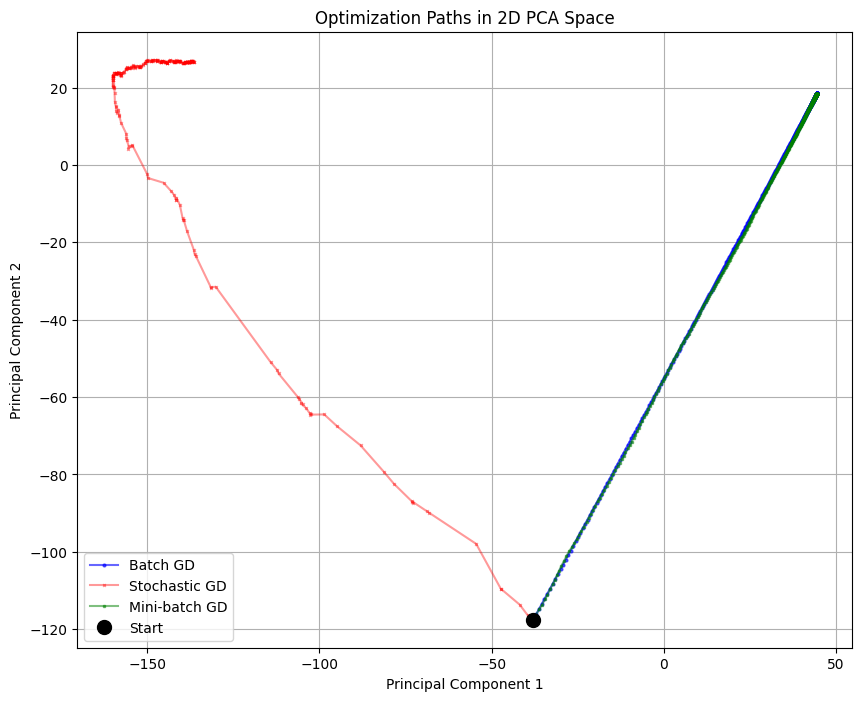

time: 263 ms (started: 2026-08-27 11:50:34 +00:00)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Combine all history to fit a common PCA projection
all_paths = np.vstack([
    theta_history_original,
    theta_history_original_sgd,
    theta_history_original_mbgd
])

pca = PCA(n_components=2)
pca.fit(all_paths)

path_bgd_2d = pca.transform(theta_history_original)
path_sgd_2d = pca.transform(theta_history_original_sgd)
path_mbgd_2d = pca.transform(theta_history_original_mbgd)

plt.figure(figsize=(10, 8))

# Plot paths
plt.plot(path_bgd_2d[:, 0], path_bgd_2d[:, 1], 'b-o', label='Batch GD', markersize=2, alpha=0.6)
plt.plot(path_sgd_2d[:, 0], path_sgd_2d[:, 1], 'r-x', label='Stochastic GD', markersize=2, alpha=0.4)
plt.plot(path_mbgd_2d[:, 0], path_mbgd_2d[:, 1], 'g-s', label='Mini-batch GD', markersize=2, alpha=0.5)

# Mark starting point
plt.plot(path_bgd_2d[0, 0], path_bgd_2d[0, 1], 'ko', markersize=10, label='Start')

plt.title('Optimization Paths in 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Polynomial regression
Reference: https://towardsdatascience.com/machine-learning-polynomial-regression-with-python-5328e4e8a386

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
df = pd.read_csv('https://raw.githubusercontent.com/ekaratnida/Applied-machine-learning/master/Week03-MLR/Position_Salaries.csv')
X = df.iloc[:, 1:2].values
y = df.iloc[:, 2].values
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
time: 138 ms (started: 2026-08-27 11:50:13 +00:00)


[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


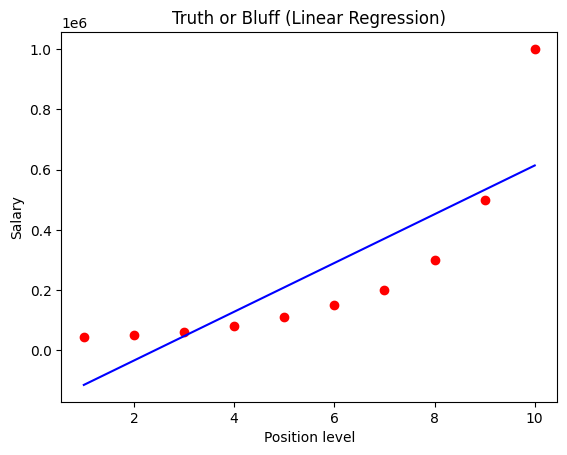

time: 146 ms (started: 2026-08-27 11:50:13 +00:00)


In [15]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(y)
# Visualizing the Linear Regression results

plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


[[   1.    1.    1.    1.]
 [   1.    2.    4.    8.]
 [   1.    3.    9.   27.]
 [   1.    4.   16.   64.]
 [   1.    5.   25.  125.]
 [   1.    6.   36.  216.]
 [   1.    7.   49.  343.]
 [   1.    8.   64.  512.]
 [   1.    9.   81.  729.]
 [   1.   10.  100. 1000.]]


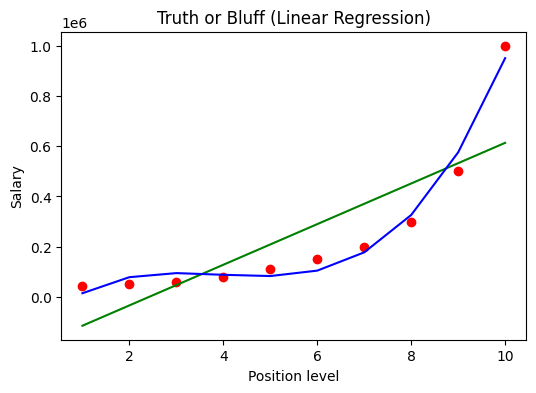

time: 143 ms (started: 2026-08-27 11:50:13 +00:00)


In [16]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)
print(X_poly)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

# Visualizing the Polymonial Regression results
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='green')
plt.plot(X, pol_reg.predict(X_poly), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


In [17]:
# Predicting a new result with Linear Regression
print(lin_reg.predict([[5.5]]))

# Predicting a new result with Polymonial Regression
print(pol_reg.predict(poly_reg.fit_transform([[5.5]])))

[249500.]
[89187.5]
time: 2.21 ms (started: 2026-08-27 11:50:13 +00:00)
